In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

def manual_ransac_homography(src_pts, dst_pts, iterations=1000, tolerance=5.0):
    """
    Handwritten RANSAC algorithm for finding the best homography matrix
    """
    best_inliers_idx = []
    best_H = None
    
    # Ensure that the number of points is greater than or equal to 4; otherwise, the homography matrix cannot be calculated.
    if len(src_pts) < 4:
        return None, []

    for _ in range(iterations):
        # 1. Randomly select the smallest subset (the homography matrix requires 4 pairs of points)
        idx = random.sample(range(len(src_pts)), 4)
        pts1 = src_pts[idx]
        pts2 = dst_pts[idx]
        
        # 2. Fitting model (using the basic getPerspectiveTransform)
        try:
            # getPerspectiveTransform Only accept float32 and exactly 4 points
            H = cv2.getPerspectiveTransform(pts1, pts2)
        except Exception:
            continue # If the 4 selected points are collinear, which makes it impossible to calculate, then skip them.
            
        # 3. Determine the number of interior points (calculate the re-projection error)
        # Project all the src_pts onto the space of Figure 2 through H.
        projected_pts = cv2.perspectiveTransform(src_pts.reshape(-1, 1, 2), H)
        # Calculate the Euclidean distance
        errors = np.linalg.norm(projected_pts.squeeze() - dst_pts.squeeze(), axis=1)
        
        # Find the indices of the points whose error is less than the tolerance level.
        inlier_indices = np.where(errors < tolerance)[0]
        
        # 4. Select the model with the largest number of interior points as the best model.
        if len(inlier_indices) > len(best_inliers_idx):
            best_inliers_idx = inlier_indices
            best_H = H
            
    return best_H, best_inliers_idx

In [3]:
# read Part 2 pictures
img1 = cv2.imread('demo1.jpg') 
img2 = cv2.imread('demo2.jpg')
if img1 is None or img2 is None:
    raise ValueError("Can't find the pictures of Part2！")

# Critical Fix: Resize images to prevent memory overflow!
scale_percent = 30 #
width1 = int(img1.shape[1] * scale_percent / 100)
height1 = int(img1.shape[0] * scale_percent / 100)
img1 = cv2.resize(img1, (width1, height1), interpolation=cv2.INTER_AREA)

width2 = int(img2.shape[1] * scale_percent / 100)
height2 = int(img2.shape[0] * scale_percent / 100)
img2 = cv2.resize(img2, (width2, height2), interpolation=cv2.INTER_AREA)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

thresholds = [0.01, 0.03, 0.05, 0.1, 0.15]
inliers_counts = []
all_results = {}

print("Start testing the influence of different SIFT thresholds on RANSAC...\n")

for thresh in thresholds:
    sift = cv2.SIFT_create(contrastThreshold=thresh)
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)
    
    # 监控预警
    print(f"The threshold {thresh} is being processed... The feature points extracted are: {len(kp1)}")
    
    # If the descriptor cannot be found (for example, if the threshold is too high), skip it.
    if des1 is None or des2 is None:
        print(f"The threshold {thresh} is too strict and no feature points were found. \n)
        inliers_counts.append(0)
        continue

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
            
    if len(good_matches) >= 4:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ])
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ])
        
        H, inliers_idx = manual_ransac_homography(src_pts, dst_pts, iterations=1000, tolerance=5.0)
        num_inliers = len(inliers_idx) if inliers_idx is not None else 0
        
        inliers_counts.append(num_inliers)
        
        all_results[thresh] = {
            'kp1': kp1, 'kp2': kp2, 
            'good_matches': good_matches, 
            'inliers_idx': inliers_idx
        }
        
        print(f"-> After screening, high-quality matches: {len(good_matches)} | Final inliers of RANSAC: {num_inliers}\n")
    else:
        inliers_counts.append(0)
        print(f"-> There are less than 4 high-quality matches, so RANSAC cannot be run.\n")

print("Data collection is complete!")

开始测试不同 SIFT 阈值对 RANSAC 的影响...

正在处理阈值 0.01... 提取到图1特征点: 10619 个
-> 筛选后优质匹配: 3036 | RANSAC 最终内点: 2809

正在处理阈值 0.03... 提取到图1特征点: 6951 个
-> 筛选后优质匹配: 2465 | RANSAC 最终内点: 2284

正在处理阈值 0.05... 提取到图1特征点: 4019 个
-> 筛选后优质匹配: 1582 | RANSAC 最终内点: 1454

正在处理阈值 0.1... 提取到图1特征点: 631 个
-> 筛选后优质匹配: 277 | RANSAC 最终内点: 247

正在处理阈值 0.15... 提取到图1特征点: 201 个
-> 筛选后优质匹配: 85 | RANSAC 最终内点: 73

数据收集完毕！可以准备画图了。


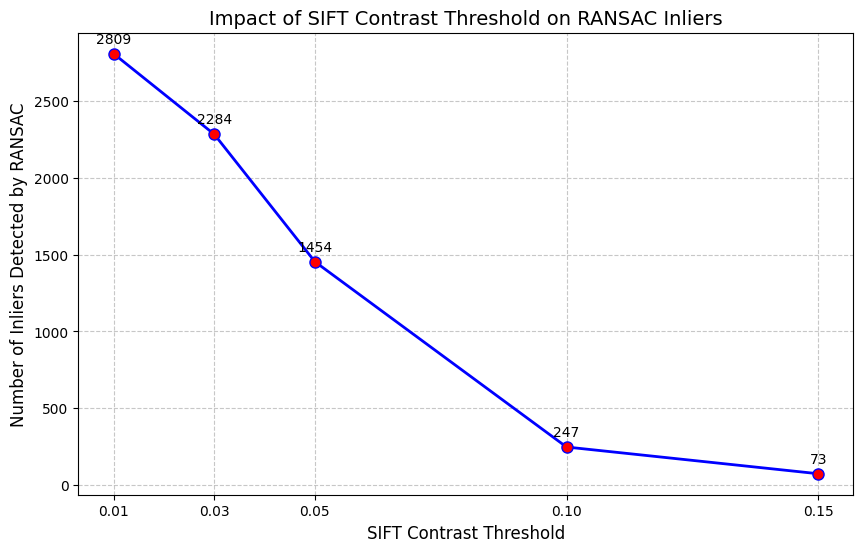

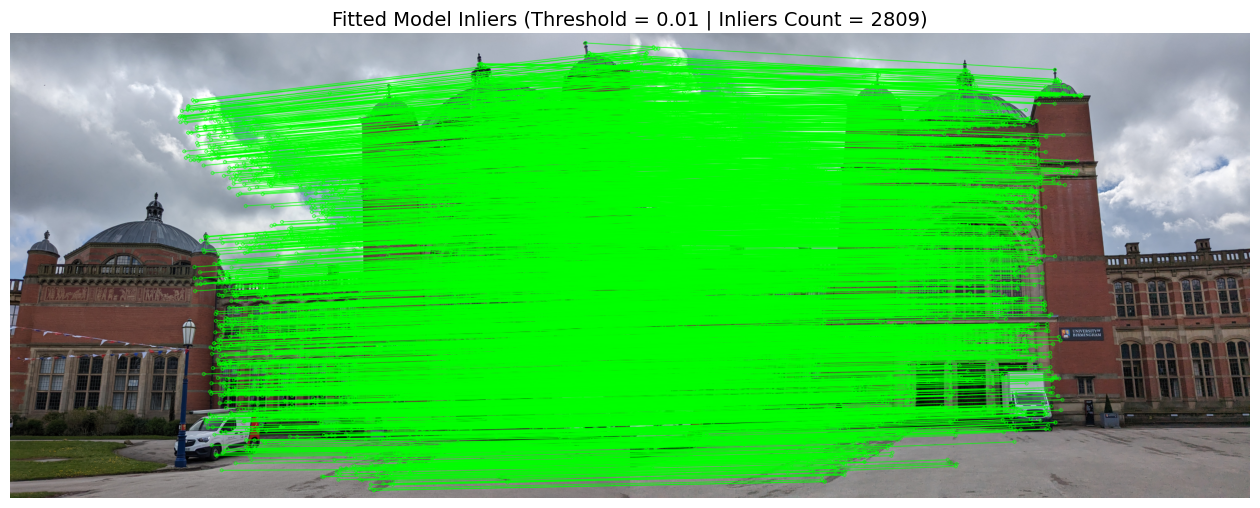

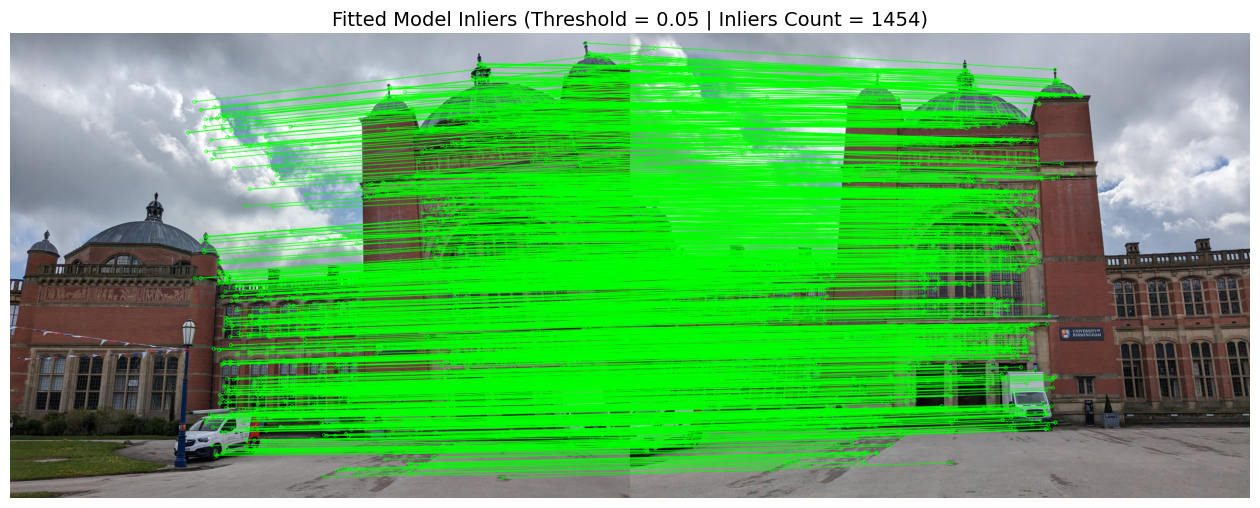

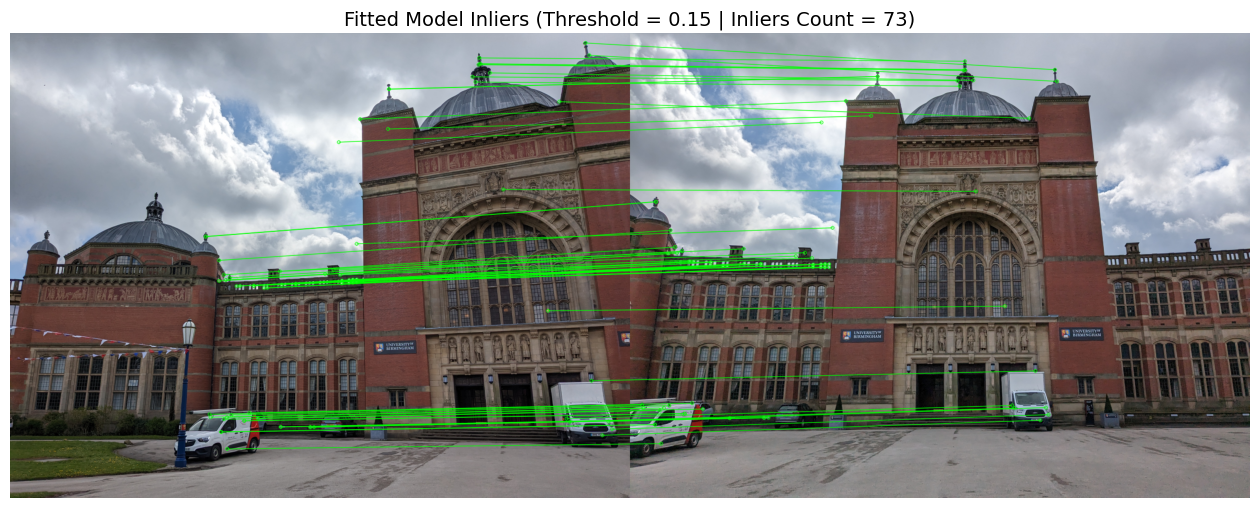

In [4]:
import matplotlib.pyplot as plt

# ==========================================
# 1. Draw a line graph: SIFT threshold vs. number of inliers
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(thresholds, inliers_counts, marker='o', markersize=8, linewidth=2, color='b', mfc='r')

# Mark specific numbers at each point to make the chart more professional.
for i, count in enumerate(inliers_counts):
    plt.text(thresholds[i], count + 50, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Impact of SIFT Contrast Threshold on RANSAC Inliers', fontsize=14)
plt.xlabel('SIFT Contrast Threshold', fontsize=12)
plt.ylabel('Number of Inliers Detected by RANSAC', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(thresholds)
plt.show()

# ==========================================
# 2. Draw three representative threshold RANSAC inlier connection diagrams
# ==========================================
# selected 0.01 (extremely low), 0.05 (moderate), and 0.15 (extremely high) for presentation.
visualize_thresh = [0.01, 0.05, 0.15]

for thresh in visualize_thresh:
    if thresh in all_results and all_results[thresh]['inliers_idx'] is not None:
        res = all_results[thresh]
        
        # 提取当前阈值下的所有 good_matches 和内点索引
        good_matches = res['good_matches']
        inliers_idx = res['inliers_idx']
        
        # 筛选出属于内点的 match 对象
        inlier_matches = [good_matches[i] for i in inliers_idx]
        
        # 使用 cv2.drawMatches 画出连线 (绿色代表 RANSAC 认证的内点)
        img_matches = cv2.drawMatches(
            img1, res['kp1'], 
            img2, res['kp2'], 
            inlier_matches, None, 
            matchColor=(0, 255, 0), # 绿色连线
            singlePointColor=(255, 0, 0),
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        
        plt.figure(figsize=(16, 8))
        plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
        plt.title(f"Fitted Model Inliers (Threshold = {thresh} | Inliers Count = {len(inlier_matches)})", fontsize=14)
        plt.axis('off')
        plt.show()